# Perpectiva económica

## Proposito del documento

El objetivo de este proceso de investigación es construir una perspectiva económica integral de Estados Unidos que permita tomar una postura sobre el ciclo económico y posteriormente, traducir esa postura en criterios de selección de activos.

La idea central es que una lectura económica robusta no debe depender únicamente de variables tradicionales como PIB, inflación, tasas de interés etc. dado que estas variables aunque explican aspectos fundamentales del ciclo económico no capturan por completo el comportamiento de los precios de los activos financieros. Por tanto, es necesario incluir otro eje en análisis: la plomeria financiera, es decir, información relacionada a la estructura de liquidez que sostieen, amplifica, o restringue el apetito por el riesgo en los mercados.

## Marco conceptual

### Perpectiva económica tradicional

La perpectiva tradicional busca identificar el estado de la económia real y su tendencia en terminos de pronosticos. Para ello observa variables como producción, consumo, inversión, empleo, inflación, salarios, tasas de interés, política monetaria, gasto público, déficit fiscal y expectativas.

Esta capa tiene la intención de responder preguntas como:

- ¿La económia está creciendo o desacelerándose?
- ¿La inflación está subiendo, bajando o permanece rígida?
- ¿El mercado laboral sigue fuerte o comienza e deteriorarse?
- ¿La Fed tiene espacio para recortar tasas o debe mantener una postura restrictiva?
- ¿El consumidor sigue sosteniendo el crecimiento?
- ¿El sector vivienda funciona como motor, freno o fuente de riesgo?

### Perspectiva de la plomeria financiera

La plomeria financiera busca entender la liquidez del sistema. En términos practivos, no basta con saber si la económia crece, también hay que conocer si el sistema financiero tiene capacidad de balance, reservas disponibles, fondeo estable, apetito de crédito y condiciones financieras suficientemente laxas para sostener precios de activos.

En esta segunda capa se pretende responder preguntas como:

- ¿La fed estas inyectando o drenando liquidez?
- La reservas bancarias son abundantes o empiezan a ser escasas?
- ¿El tesoro está drenando liquidez al aumentar su caja?
- ¿El mercado repo muestra señales de tensión?
- ¿El reverse repo refleja exceso de liquidez estacionado en la FED o su agotamiento?
- ¿Los spreads de crédito están ampliando?
- La liquidez global en dólares está creciendo o contrayendo?

# Hipótesis rectora

> *Los activos financieros responden de manera proporcional y simultanea a fundamentos económicos y a condiciones de liquidez.*

Es decir, una perpectiva de inversión integral y robusta debe combinar el análisis macroeconómico tradicional ycon una lectura de la plomería financiera.

Esto significa que en dos economías con el mismo crecimiento e inflación pueden tener implicaciones de mercado completamente distintas si una opera con liquidez abundante y otra con liquidez restrictiva.

| Combinación | Lectura general |
|---|---|
| Crecimiento fuerte + liquidez abundante | Suele favorecer activos de riesgo. |
| Crecimiento fuerte + liquidez restrictiva | Puede favorecer activos de calidad, pero limita activos especulativos. |
| Desaceleración + liquidez abundante | Puede sostener rallies financieros aun con fundamentos débiles. |
| Desaceleración + liquidez restrictiva | Aumenta el riesgo de corrección en equity, crédito high yield y activos ilíquidos. |
| Recesión + estrés financiero | Suele favorecer cash, Treasuries y activos defensivos. |

# Análisis económico

In [1]:
from pathlib import Path
from dataclasses import replace

from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# ============================================================
# Configuracion maestra del reporte
# Todo lo importante debe poder modificarse desde aqui.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import display, Markdown

from src.client_policy import mexican_moderate_aggressive_growth_policy
from src.research.macro_liquidity import (
    EconomicSeriesSpec,
    ProviderConfig,
    ProviderCredentials,
    ProviderRegistry,
    default_us_macro_liquidity_catalog,
    DataPolicy,
    ValidationPolicy,
    ConfidencePolicy,
    ForecastPolicy,
    ScenarioPolicy,
    AuditPolicy,
    MacroLiquidityPolicy,
    MacroLiquidityWorkflow,
    ScenarioOverride,
)

REPORT_CONFIG = {
    "title": "Reporte Macroeconómico y de Liquidez",
    "subtitle": "Postura top-down para tesis de inversión y selección de activos",
    "author": "Rigo / Codex",
    "as_of": "2026-05-09",
    "start_date": "2010-01-01",
    "base_horizon_months": 3,
    "fallback_horizon_months": 6,
    "strategic_horizon_months": 12,
    "write_audit": True,
}

OUTPUT_DIR = Path("research/outputs/macro_liquidity_report")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"""
# {REPORT_CONFIG["title"]}

**{REPORT_CONFIG["subtitle"]}**  
**Fecha de corte:** {REPORT_CONFIG["as_of"]}  
**Autor:** {REPORT_CONFIG["author"]}
"""))



# Reporte Macroeconómico y de Liquidez

**Postura top-down para tesis de inversión y selección de activos**  
**Fecha de corte:** 2026-05-09  
**Autor:** Rigo / Codex


In [3]:
# ============================================================
# Estilo visual inspirado en el memo MELI
# ============================================================

STYLE = {
    "navy": "#1E3D70",
    "blue": "#7E93B0",
    "pale": "#D8DEE7",
    "dark": "#0A3850",
    "softgray": "#F2F3F5",
    "text": "#343A40",
    "positive": "#2E7D32",
    "negative": "#B23A48",
    "neutral": "#7A7A7A",
}

mpl.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 130,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": STYLE["pale"],
    "axes.labelcolor": STYLE["text"],
    "xtick.color": STYLE["text"],
    "ytick.color": STYLE["text"],
    "text.color": STYLE["text"],
    "font.family": "serif",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": STYLE["navy"],
    "axes.grid": True,
    "grid.color": STYLE["softgray"],
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

def clean_axis(ax, title=None, subtitle=None):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color(STYLE["pale"])
    ax.spines["bottom"].set_color(STYLE["pale"])
    if title:
        ax.set_title(title, loc="left", pad=14)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=STYLE["blue"], fontsize=9)
    return ax


In [4]:
# ============================================================
# Revision de proveedores de datos
# ============================================================

credentials = ProviderCredentials()
provider_config = ProviderConfig(credentials=credentials)

availability = provider_config.availability_report()
display(availability)

ready_providers = availability.loc[availability["ready_for_fetch"], "provider"].tolist()
missing_providers = availability.loc[
    availability["provider_implemented"] & ~availability["ready_for_fetch"],
    ["provider", "env_var", "notes"]
]

display(Markdown(f"""
## Lectura operativa

Providers listos para descargar: **{ready_providers}**

Providers implementados pero no listos por credencial faltante:
"""))
display(missing_providers)


,provider,provider_registered,provider_implemented,requires_key,env_var,token_configured,credential_available,ready_for_fetch,available,base_url,notes
0,FRED,True,True,True,FRED_API_KEY,True,True,True,True,https://api.stlouisfed.org/fred,Official API requires a key.
1,BEA,True,True,True,BEA_API_KEY,True,True,True,True,https://apps.bea.gov/api/data,Free key after registration.
2,BLS,True,True,False,BLS_API_KEY,False,True,True,True,https://api.bls.gov/publicAPI,Some endpoints work without a key; v2 benefits...
3,CENSUS,True,False,False,CENSUS_API_KEY,False,True,False,True,https://api.census.gov/data,Key recommended for higher limits.
4,FED_DDP,True,True,False,NaN,False,True,True,True,https://www.federalreserve.gov/datadownload,CSV/XML/SDMX downloads.
5,NY_FED,True,False,False,NaN,False,True,False,True,https://markets.newyorkfed.org/api,Markets and reference-rate data.
6,TREASURY,True,True,False,NaN,False,True,True,True,https://api.fiscaldata.treasury.gov/services/a...,Fiscal Data API.
7,EIA,True,False,True,EIA_API_KEY,False,False,False,False,https://api.eia.gov/v2,Official API requires a key.
8,BIS,True,False,False,NaN,False,True,False,True,https://stats.bis.org/api/v2,SDMX-style data access.
9,INEGI,True,False,True,INEGI_TOKEN,False,False,False,False,https://www.inegi.org.mx/app/api/indicadores/d...,Token required for indicator API.



## Lectura operativa

Providers listos para descargar: **['FRED', 'BEA', 'BLS', 'FED_DDP', 'TREASURY']**

Providers implementados pero no listos por credencial faltante:


,provider,env_var,notes


In [5]:
# ============================================================
# Indicadores macro tradicionales adicionales
# ============================================================

macro_specs = (
    # empleo
    EconomicSeriesSpec(
        "bls_unemployment_rate",
        "macro",
        "labor",
        False,
        provider="BLS",
        provider_code="LNS14000000",
        frequency="M",
        transform="level",
        periods=1,
        weight=1.2,
        required=True,
        description="Tasa de desempleo. Más alta suele indicar deterioro laboral.",
    ),
    EconomicSeriesSpec(
        "bls_nonfarm_payrolls",
        "macro",
        "labor",
        True,
        provider="BLS",
        provider_code="CES0000000001",
        frequency="M",
        transform="yoy_change",
        periods=12,
        description="Empleo no agrícola. Crecimiento anual positivo indica fortaleza laboral.",
    ),

    # politica fiscal
    EconomicSeriesSpec(
        "federal_surplus_deficit_gdp",
        "macro",
        "fiscal_policy",
        True,
        provider="FRED",
        provider_code="FYFSGDA188S",
        frequency="Q",
        transform="level",
        periods=1,
        description="Superávit/déficit fiscal como porcentaje del PIB. Mayor valor implica mejor balance fiscal.",
    ),
    EconomicSeriesSpec(
        "federal_debt_public_gdp",
        "macro",
        "fiscal_policy",
        False,
        provider="FRED",
        provider_code="GFDEGDQ188S",
        frequency="Q",
        transform="level",
        periods=1,
        description="Deuda pública como porcentaje del PIB. Mayor deuda reduce espacio fiscal.",
    ),
    EconomicSeriesSpec(
        "federal_current_expenditures",
        "macro",
        "fiscal_policy",
        True,
        provider="FRED",
        provider_code="FGEXPND",
        frequency="Q",
        transform="yoy_change",
        periods=4,
        description="Gasto corriente federal. Puede capturar impulso fiscal de corto plazo.",
    ),

    # vivienda
    EconomicSeriesSpec(
        "housing_starts",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="HOUST",
        frequency="M",
        transform="yoy_change",
        periods=12,
        description="Inicios de vivienda. Señal cíclica de construcción e inversión residencial.",
    ),
    EconomicSeriesSpec(
        "building_permits",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="PERMIT",
        frequency="M",
        transform="yoy_change",
        periods=12,
        description="Permisos de construcción. Indicador adelantado del ciclo de vivienda.",
    ),
    EconomicSeriesSpec(
        "case_shiller_home_price_index",
        "macro",
        "housing",
        True,
        provider="FRED",
        provider_code="CSUSHPISA",
        frequency="M",
        transform="yoy_change",
        periods=12,
        description="Precios de vivienda. Sube con riqueza del hogar, pero también puede reflejar presión de affordability.",
    ),
    EconomicSeriesSpec(
        "mortgage_30y_rate",
        "macro",
        "housing",
        False,
        provider="FRED",
        provider_code="MORTGAGE30US",
        frequency="W",
        transform="level",
        periods=1,
        description="Tasa hipotecaria a 30 años. Tasas altas restringen vivienda.",
    ),

    # energia
    EconomicSeriesSpec(
        "wti_crude_oil",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="DCOILWTICO",
        frequency="D",
        transform="yoy_change",
        periods=252,
        description="WTI anualizado aproximado por días de mercado. Energía al alza presiona inflación.",
    ),
    EconomicSeriesSpec(
        "regular_gasoline_price",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="GASREGW",
        frequency="W",
        transform="yoy_change",
        periods=52,
        description="Gasolina regular. Impacta ingreso disponible y expectativas de inflación.",
    ),
    EconomicSeriesSpec(
        "cpi_energy",
        "macro",
        "energy",
        False,
        provider="FRED",
        provider_code="CPIENGSL",
        frequency="M",
        transform="yoy_change",
        periods=12,
        description="CPI de energía. Captura presión inflacionaria energética.",
    ),

    # expectativas
    EconomicSeriesSpec(
        "consumer_sentiment",
        "macro",
        "expectations",
        True,
        provider="FRED",
        provider_code="UMCSENT",
        frequency="M",
        transform="level",
        periods=1,
        weight=1.1,
        description="Sentimiento del consumidor. Señal de confianza y disposición a gastar.",
    ),
    EconomicSeriesSpec(
        "michigan_inflation_expectations",
        "macro",
        "expectations",
        False,
        provider="FRED",
        provider_code="MICH",
        frequency="M",
        transform="level",
        periods=1,
        description="Expectativas de inflación de Michigan. Más altas complican recortes de la Fed.",
    ),
    EconomicSeriesSpec(
        "five_year_breakeven_inflation",
        "macro",
        "expectations",
        False,
        provider="FRED",
        provider_code="T5YIE",
        frequency="D",
        transform="level",
        periods=1,
        description="Breakeven de inflación a 5 años. Proxy de expectativas de mercado.",
    ),
)


In [6]:
# ============================================================
# Indicadores adicionales de plomeria financiera
# ============================================================

liquidity_specs = (
    EconomicSeriesSpec(
        "fred_fed_assets",
        "liquidity",
        "fed_liquidity",
        True,
        provider="FRED",
        provider_code="WALCL",
        frequency="W",
        transform="yoy_change",
        periods=52,
        weight=1.1,
        description="Balance total de la Fed. Crecimiento suele indicar liquidez expansiva.",
    ),
    EconomicSeriesSpec(
        "fred_reserve_balances",
        "liquidity",
        "fed_liquidity",
        True,
        provider="FRED",
        provider_code="WRESBAL",
        frequency="W",
        transform="yoy_change",
        periods=52,
        weight=1.3,
        required=True,
        description="Reservas bancarias. Núcleo de liquidez del sistema bancario.",
    ),
    EconomicSeriesSpec(
        "fred_reverse_repo",
        "liquidity",
        "fed_liquidity",
        False,
        provider="FRED",
        provider_code="RRPONTSYD",
        frequency="D",
        transform="level",
        periods=1,
        description="Reverse repo. Alto nivel puede representar liquidez estacionada; caída puede liberar liquidez.",
    ),
    EconomicSeriesSpec(
        "fred_tga",
        "liquidity",
        "treasury_liquidity",
        False,
        provider="FRED",
        provider_code="WTREGEN",
        frequency="W",
        transform="level",
        periods=1,
        weight=1.1,
        description="Cuenta General del Tesoro. Cuando sube, suele drenar reservas del sistema.",
    ),
    EconomicSeriesSpec(
        "fred_sofr",
        "liquidity",
        "funding",
        False,
        provider="FRED",
        provider_code="SOFR",
        frequency="D",
        transform="level",
        periods=1,
        description="SOFR. Proxy de costo de fondeo garantizado en dólares.",
    ),
    EconomicSeriesSpec(
        "fred_nfci",
        "liquidity",
        "financial_conditions",
        False,
        provider="FRED",
        provider_code="NFCI",
        frequency="W",
        transform="level",
        periods=1,
        weight=1.3,
        required=True,
        description="National Financial Conditions Index. Mayor valor implica condiciones más restrictivas.",
    ),
    EconomicSeriesSpec(
        "fred_hy_oas",
        "liquidity",
        "financial_conditions",
        False,
        provider="FRED",
        provider_code="BAMLH0A0HYM2",
        frequency="D",
        transform="level",
        periods=1,
        weight=1.2,
        description="High Yield OAS. Spreads más altos indican mayor estrés crediticio.",
    ),
    EconomicSeriesSpec(
        "fred_bank_credit",
        "liquidity",
        "credit",
        True,
        provider="FRED",
        provider_code="TOTBKCR",
        frequency="W",
        transform="yoy_change",
        periods=52,
        description="Crédito bancario total. Expansión indica transmisión crediticia.",
    ),
    EconomicSeriesSpec(
        "fred_ci_loans",
        "liquidity",
        "credit",
        True,
        provider="FRED",
        provider_code="BUSLOANS",
        frequency="W",
        transform="yoy_change",
        periods=52,
        description="Préstamos comerciales e industriales. Señal de crédito al sector productivo.",
    ),
    EconomicSeriesSpec(
        "fred_broad_dollar",
        "liquidity",
        "global_dollar_liquidity",
        False,
        provider="FRED",
        provider_code="DTWEXBGS",
        frequency="D",
        transform="level",
        periods=1,
        description="Dólar amplio. Dólar fuerte suele apretar liquidez global.",
    ),
    EconomicSeriesSpec(
        "vix",
        "liquidity",
        "risk_appetite",
        False,
        provider="FRED",
        provider_code="VIXCLS",
        frequency="D",
        transform="level",
        periods=1,
        description="VIX. Proxy de aversión al riesgo y demanda de cobertura.",
    ),
)


In [11]:
# ============================================================
# Universo final de indicadores
# ============================================================

USE_DEFAULT_CATALOG = True
USE_MACRO_EXTENSION = True
USE_LIQUIDITY_EXTENSION = True

specs = []

if USE_DEFAULT_CATALOG:
    specs.extend(default_us_macro_liquidity_catalog())

if USE_MACRO_EXTENSION:
    specs.extend(macro_specs)

if USE_LIQUIDITY_EXTENSION:
    specs.extend(liquidity_specs)

# Evitar duplicados por nombre, conservando la ultima definicion.
specs_by_name = {spec.name: spec for spec in specs}
specs = tuple(specs_by_name.values())

catalog = pd.DataFrame([spec.__dict__ for spec in specs])

display(Markdown(f"## Catálogo final: {len(specs)} indicadores"))
display(catalog[[
    "name", "engine", "block", "provider", "provider_code",
    "frequency", "transform", "periods", "weight", "required"
]].sort_values(["engine", "block", "name"]))


## Catálogo final: 44 indicadores

,name,engine,block,provider,provider_code,frequency,transform,periods,weight,required
27,banxico_usd_mxn,liquidity,client_currency,BANXICO,SF63528,D,level,1,1.0,False
24,fred_bank_credit,liquidity,credit,FRED,TOTBKCR,W,yoy_change,52,1.0,False
25,fred_ci_loans,liquidity,credit,FRED,BUSLOANS,W,yoy_change,52,1.0,False
16,fred_fed_assets,liquidity,fed_liquidity,FRED,WALCL,W,yoy_change,52,1.1,False
17,fred_reserve_balances,liquidity,fed_liquidity,FRED,WRESBAL,W,yoy_change,52,1.3,True
18,fred_reverse_repo,liquidity,fed_liquidity,FRED,RRPONTSYD,D,level,1,1.0,False
23,fred_hy_oas,liquidity,financial_conditions,FRED,BAMLH0A0HYM2,D,level,1,1.2,False
22,fred_kcfsi,liquidity,financial_conditions,FRED,KCFSI,M,level,1,1.0,False
21,fred_nfci,liquidity,financial_conditions,FRED,NFCI,W,level,1,1.3,True
20,fred_sofr,liquidity,funding,FRED,SOFR,D,level,1,1.0,False


## Politica metodologica

In [8]:
# ============================================================
# Politica metodologica
# ============================================================

data_policy = DataPolicy(
    data_mode="revised",
    real_time_safe=False,
    canonical_frequency="M",
    rebalance_frequency="Q",
    quarterly_interpolation="linear",
    publication_lag_days_by_frequency={
        "D": 1,
        "W": 3,
        "M": 15,
        "Q": 45,
        "A": 90,
        "Y": 90,
    },
)

validation_policy = ValidationPolicy(
    min_history_months=48,
    max_missing_ratio=0.25,
    min_signal_stability=0.50,
    candidate_weight_multiplier=0.60,
)

confidence_policy = ConfidencePolicy(
    coverage_weight=0.35,
    agreement_weight=0.25,
    stability_weight=0.20,
    freshness_weight=0.10,
    narrative_weight=0.10,
    contradiction_threshold=0.50,
)

forecast_policy = ForecastPolicy(
    horizons_months=(
        REPORT_CONFIG["base_horizon_months"],
        REPORT_CONFIG["fallback_horizon_months"],
        REPORT_CONFIG["strategic_horizon_months"],
    ),
    base_horizon_months=REPORT_CONFIG["base_horizon_months"],
    fallback_horizon_months=REPORT_CONFIG["fallback_horizon_months"],
    strategic_horizon_months=REPORT_CONFIG["strategic_horizon_months"],
    benchmark_model="ar1",
    diagnostic_benchmark_models=("naive", "drift"),
    candidate_models=("mean_reversion", "ets", "auto_sarima"),
    selection_metric="rmse",
    min_improvement_over_benchmark=0.03,
    minimum_train_months=36,
    rolling_initial_train_months=36,
    rolling_forecast_horizon=3,
    ewma_lambda=0.94,
    confidence_interval_z=1.64,
    bootstrap_iterations=250,
    bootstrap_random_seed=42,
)

scenario_policy = ScenarioPolicy(
    base_floor=0.40,
    base_confidence_slope=0.30,
    downside_base=0.35,
    downside_confidence_penalty=0.15,
    liquidity_stress_penalty=0.10,
)

audit_policy = AuditPolicy(
    run_root="research/data/research_runs",
    write_artifacts=True,
)

policy = MacroLiquidityPolicy(
    data=data_policy,
    validation=validation_policy,
    confidence=confidence_policy,
    forecast=forecast_policy,
    scenario=scenario_policy,
    audit=audit_policy,
)

display(pd.Series(policy.methodology_summary(), name="valor"))


data_mode                                                    revised
real_time_safe                                                 False
canonical_frequency                                                M
rebalance_frequency                                                Q
quarterly_interpolation                                       linear
forecast_horizons_months                                  (3, 6, 12)
base_horizon_months                                                3
strategic_horizon_months                                          12
fallback_horizon_months                                            6
benchmark_model                                                  ar1
diagnostic_benchmark_models                           (naive, drift)
candidate_models                  (mean_reversion, ets, auto_sarima)
selection_metric                                                rmse
min_improvement_over_benchmark                                  0.03
rolling_initial_train_months      

Descarga de datos

In [9]:
# ============================================================
# Descarga de datos
# ============================================================

credentials = ProviderCredentials()
provider_config = ProviderConfig(credentials=credentials)
registry = ProviderRegistry.default_us(config=provider_config)

provider_availability = provider_config.availability_report()
display(provider_availability)

,provider,provider_registered,provider_implemented,requires_key,env_var,token_configured,credential_available,ready_for_fetch,available,base_url,notes
0,FRED,True,True,True,FRED_API_KEY,True,True,True,True,https://api.stlouisfed.org/fred,Official API requires a key.
1,BEA,True,True,True,BEA_API_KEY,True,True,True,True,https://apps.bea.gov/api/data,Free key after registration.
2,BLS,True,True,False,BLS_API_KEY,False,True,True,True,https://api.bls.gov/publicAPI,Some endpoints work without a key; v2 benefits...
3,CENSUS,True,False,False,CENSUS_API_KEY,False,True,False,True,https://api.census.gov/data,Key recommended for higher limits.
4,FED_DDP,True,True,False,NaN,False,True,True,True,https://www.federalreserve.gov/datadownload,CSV/XML/SDMX downloads.
5,NY_FED,True,False,False,NaN,False,True,False,True,https://markets.newyorkfed.org/api,Markets and reference-rate data.
6,TREASURY,True,True,False,NaN,False,True,True,True,https://api.fiscaldata.treasury.gov/services/a...,Fiscal Data API.
7,EIA,True,False,True,EIA_API_KEY,False,False,False,False,https://api.eia.gov/v2,Official API requires a key.
8,BIS,True,False,False,NaN,False,True,False,True,https://stats.bis.org/api/v2,SDMX-style data access.
9,INEGI,True,False,True,INEGI_TOKEN,False,False,False,False,https://www.inegi.org.mx/app/api/indicadores/d...,Token required for indicator API.


In [14]:
series_data = registry.fetch(
    specs=specs,
    start=REPORT_CONFIG["start_date"],
    end=REPORT_CONFIG["as_of"],
)

provider_errors = registry.error_report()

coverage_table = (
    series_data
    .groupby("series")["date"]
    .agg(["min", "max", "count"])
    .reset_index()
    .sort_values("series")
)

display(Markdown("## Cobertura descargada"))
display(coverage_table)

display(Markdown("## Errores de proveedor"))
display(provider_errors)

## Cobertura descargada

,series,min,max,count
0,bls_nonfarm_payrolls,2010-01-31,2019-12-31,120
1,bls_unemployment_rate,2010-01-31,2019-12-31,120
2,building_permits,2010-01-01,2026-03-01,195
3,case_shiller_home_price_index,2010-01-01,2026-02-01,194
4,consumer_sentiment,2010-01-01,2026-03-01,195
5,cpi_energy,2010-01-01,2026-03-01,194
6,federal_current_expenditures,2010-01-01,2026-01-01,65
7,federal_debt_public_gdp,2010-01-01,2025-10-01,64
8,federal_surplus_deficit_gdp,2010-01-01,2025-01-01,16
9,five_year_breakeven_inflation,2010-01-04,2026-05-08,4090


## Errores de proveedor

,provider,series,error_type,message


In [ ]:
# ============================================================
# Ejecucion del workflow macro/liquidez
# ============================================================

client_policy = mexican_moderate_aggressive_growth_policy()

scenario_overrides = [
    # Ejemplo:
    # ScenarioOverride(
    #     scenario_name="downside",
    #     probability=0.30,
    #     rationale="Ampliacion reciente de spreads no capturada completamente por el modelo.",
    #     approved_by="investment_committee",
    # )
]

workflow = MacroLiquidityWorkflow(
    specs=specs,
    policy=policy,
    min_periods=6,
)

result = workflow.run(
    series_data=series_data,
    as_of=REPORT_CONFIG["as_of"],
    client_policy=client_policy,
    scenario_overrides=scenario_overrides,
    provider_errors=provider_errors,
    write_audit=REPORT_CONFIG["write_audit"],
)

tables = result.summary_tables()

display(Markdown(f"""
## Diagnóstico central

**Régimen actual:** {result.regime_view.current.label()}  
**Régimen esperado:** {result.regime_view.expected.label()}  
**Transición:** {result.regime_view.transition}  
**Confianza:** {result.regime_view.confidence:.1%}  
**Carpeta de auditoría:** `{result.audit_dir}`
"""))



## Diagnóstico central

**Régimen actual:** recesion_desinflacionaria + neutral  
**Régimen esperado:** estanflacion + neutral  
**Transición:** recesion_desinflacionaria+neutral -> estanflacion+neutral  
**Confianza:** 54.0%  
**Carpeta de auditoría:** `research/data/research_runs/20260511T041341Z_18fba4f8`


## Macro tradicional

In [ ]:
# ============================================================
# Tabla para responder preguntas macro tradicionales
# ============================================================

macro_questions = {
    "growth": "¿La economía está creciendo o desacelerándose?",
    "inflation": "¿La inflación está subiendo, bajando o permanece rígida?",
    "labor": "¿El mercado laboral sigue fuerte o empieza a deteriorarse?",
    "policy": "¿La Fed tiene espacio para recortar tasas o debe mantener postura restrictiva?",
    "consumer": "¿El consumidor sigue sosteniendo el crecimiento?",
    "housing": "¿El sector vivienda funciona como motor, freno o fuente de riesgo?",
    "fiscal_policy": "¿La política fiscal está estimulando o deteriorando la calidad macro?",
    "expectations": "¿Las expectativas confirman o contradicen los datos duros?",
    "energy": "¿La energía está reduciendo o elevando presión inflacionaria?",
}

block_scores = result.nowcast.block_scores.copy()
latest_date = block_scores["date"].max()
latest_blocks = block_scores[block_scores["date"] == latest_date].copy()

macro_answer_table = latest_blocks[latest_blocks["engine"] == "macro"].copy()
macro_answer_table["question"] = macro_answer_table["block"].map(macro_questions)
macro_answer_table["interpretation"] = np.select(
    [
        macro_answer_table["score"] >= 0.50,
        macro_answer_table["score"] <= -0.50,
    ],
    [
        "Señal favorable frente a su historia reciente.",
        "Señal restrictiva o de deterioro frente a su historia reciente.",
    ],
    default="Señal neutral o mixta.",
)

display(macro_answer_table[[
    "block", "question", "score", "coverage",
    "available_indicators", "total_indicators", "interpretation"
]].sort_values("block"))


,block,question,score,coverage,available_indicators,total_indicators,interpretation
2844,energy,¿La energía está reduciendo o elevando presión...,-0.782479,0.5,1,2,Señal restrictiva o de deterioro frente a su h...
2845,expectations,¿Las expectativas confirman o contradicen los ...,-1.431109,1.0,1,1,Señal restrictiva o de deterioro frente a su h...
2846,labor,¿El mercado laboral sigue fuerte o empieza a d...,0.339877,1.0,1,1,Señal neutral o mixta.
2847,policy,¿La Fed tiene espacio para recortar tasas o de...,-1.172911,1.0,3,3,Señal restrictiva o de deterioro frente a su h...


## Plomeria financiera

In [ ]:
# ============================================================
# Tabla para responder preguntas macro tradicionales
# ============================================================

macro_questions = {
    "growth": "¿La economía está creciendo o desacelerándose?",
    "inflation": "¿La inflación está subiendo, bajando o permanece rígida?",
    "labor": "¿El mercado laboral sigue fuerte o empieza a deteriorarse?",
    "policy": "¿La Fed tiene espacio para recortar tasas o debe mantener postura restrictiva?",
    "consumer": "¿El consumidor sigue sosteniendo el crecimiento?",
    "housing": "¿El sector vivienda funciona como motor, freno o fuente de riesgo?",
    "fiscal_policy": "¿La política fiscal está estimulando o deteriorando la calidad macro?",
    "expectations": "¿Las expectativas confirman o contradicen los datos duros?",
    "energy": "¿La energía está reduciendo o elevando presión inflacionaria?",
}

block_scores = result.nowcast.block_scores.copy()
latest_date = block_scores["date"].max()
latest_blocks = block_scores[block_scores["date"] == latest_date].copy()

macro_answer_table = latest_blocks[latest_blocks["engine"] == "macro"].copy()
macro_answer_table["question"] = macro_answer_table["block"].map(macro_questions)
macro_answer_table["interpretation"] = np.select(
    [
        macro_answer_table["score"] >= 0.50,
        macro_answer_table["score"] <= -0.50,
    ],
    [
        "Señal favorable frente a su historia reciente.",
        "Señal restrictiva o de deterioro frente a su historia reciente.",
    ],
    default="Señal neutral o mixta.",
)

display(macro_answer_table[[
    "block", "question", "score", "coverage",
    "available_indicators", "total_indicators", "interpretation"
]].sort_values("block"))


,block,question,score,coverage,available_indicators,total_indicators,interpretation
2844,energy,¿La energía está reduciendo o elevando presión...,-0.782479,0.5,1,2,Señal restrictiva o de deterioro frente a su h...
2845,expectations,¿Las expectativas confirman o contradicen los ...,-1.431109,1.0,1,1,Señal restrictiva o de deterioro frente a su h...
2846,labor,¿El mercado laboral sigue fuerte o empieza a d...,0.339877,1.0,1,1,Señal neutral o mixta.
2847,policy,¿La Fed tiene espacio para recortar tasas o de...,-1.172911,1.0,3,3,Señal restrictiva o de deterioro frente a su h...


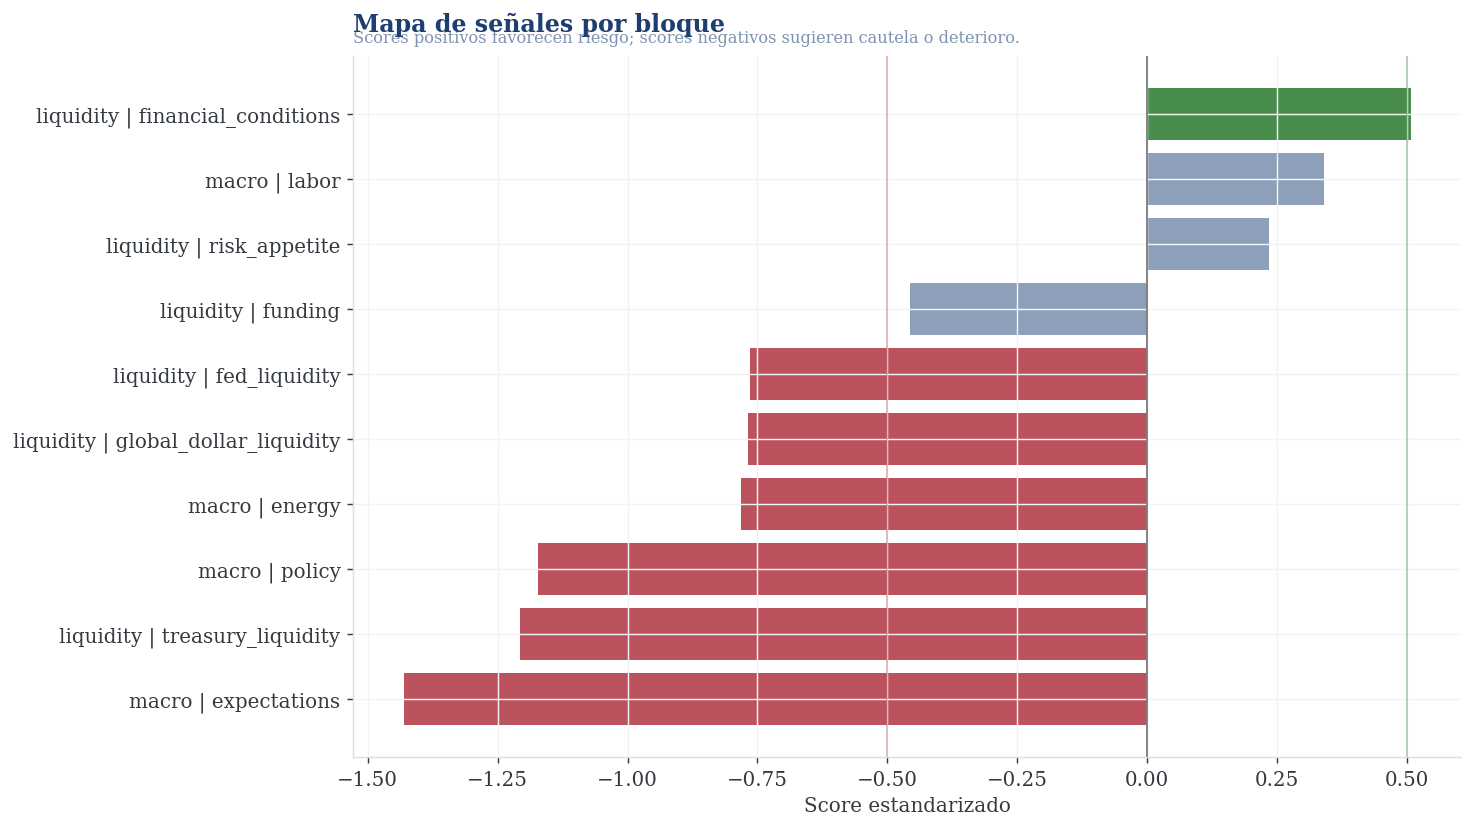

In [ ]:
# ============================================================
# Grafica: scores por bloque macro y liquidez
# ============================================================

plot_blocks = latest_blocks.copy()
plot_blocks["label"] = plot_blocks["engine"] + " | " + plot_blocks["block"]
plot_blocks = plot_blocks.sort_values("score")

colors = np.where(
    plot_blocks["score"] >= 0.50,
    STYLE["positive"],
    np.where(plot_blocks["score"] <= -0.50, STYLE["negative"], STYLE["blue"])
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_blocks["label"], plot_blocks["score"], color=colors, alpha=0.88)
ax.axvline(0, color=STYLE["neutral"], lw=1)
ax.axvline(0.5, color=STYLE["positive"], lw=1, alpha=0.35)
ax.axvline(-0.5, color=STYLE["negative"], lw=1, alpha=0.35)

clean_axis(
    ax,
    title="Mapa de señales por bloque",
    subtitle="Scores positivos favorecen riesgo; scores negativos sugieren cautela o deterioro."
)
ax.set_xlabel("Score estandarizado")
plt.show()


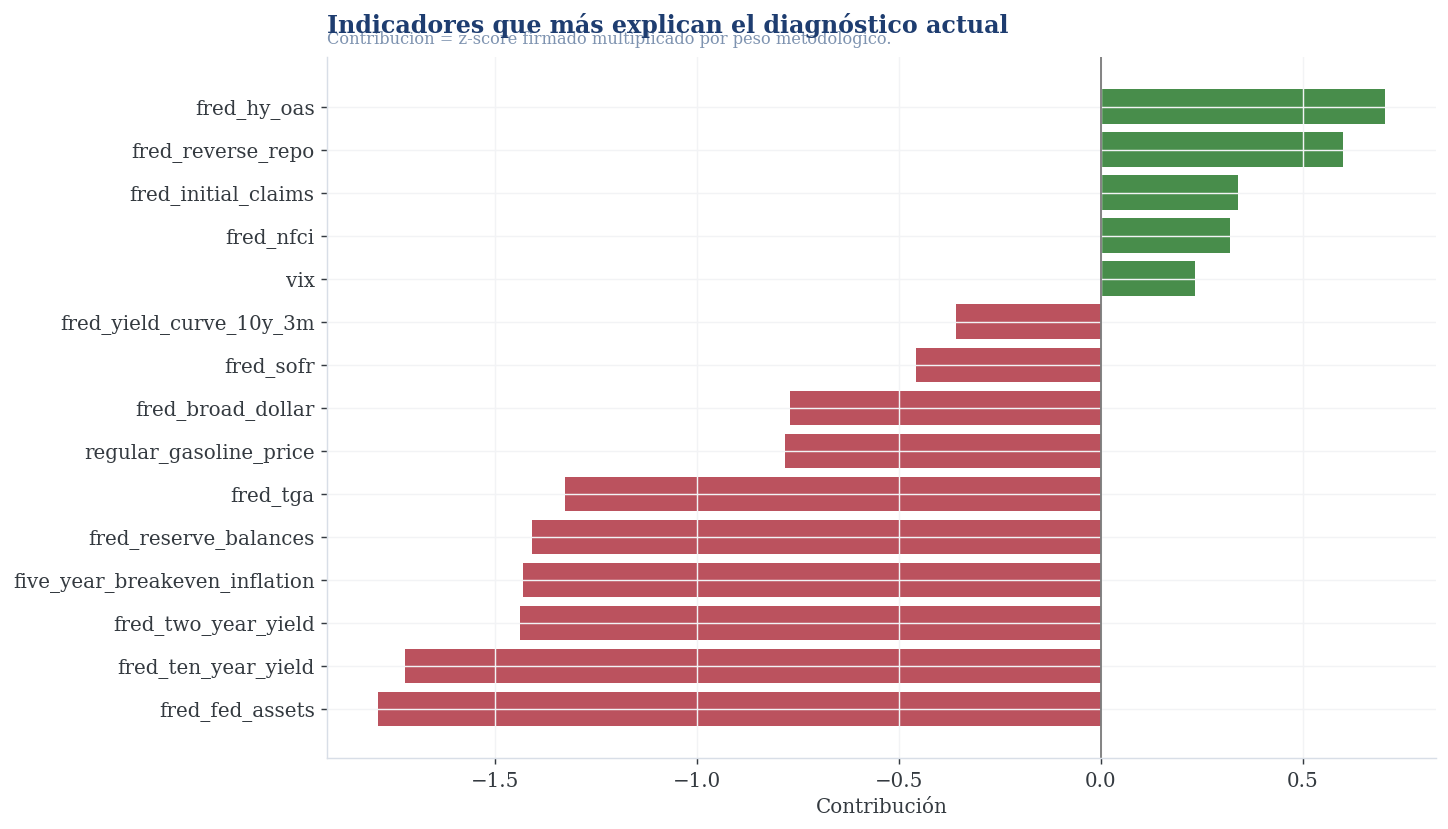

,engine,block,series,signal,signed_zscore,weight,contribution
0,liquidity,fed_liquidity,fred_fed_assets,-0.242761,-1.627863,1.10,-1.790650
1,macro,policy,fred_ten_year_yield,4.410000,-1.723364,1.00,-1.723364
2,macro,policy,fred_two_year_yield,3.920000,-1.437873,1.00,-1.437873
3,macro,expectations,five_year_breakeven_inflation,2.620000,-1.431109,1.00,-1.431109
4,liquidity,fed_liquidity,fred_reserve_balances,-0.201146,-1.083765,1.30,-1.408895
5,liquidity,treasury_liquidity,fred_tga,877761.000000,-1.207045,1.10,-1.327750
6,macro,energy,regular_gasoline_price,0.321853,-0.782479,1.00,-0.782479
7,liquidity,global_dollar_liquidity,fred_broad_dollar,118.392600,-0.768778,1.00,-0.768778
10,liquidity,funding,fred_sofr,3.600000,-0.456861,1.00,-0.456861
11,macro,policy,fred_yield_curve_10y_3m,0.690000,-0.357495,1.00,-0.357495


In [ ]:
# ============================================================
# Contribuidores principales al nowcast
# ============================================================

contributors = tables["nowcast_contributors"].copy()
contributors = contributors.dropna(subset=["contribution"]).head(15)
contributors = contributors.sort_values("contribution")

colors = np.where(contributors["contribution"] >= 0, STYLE["positive"], STYLE["negative"])

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(contributors["series"], contributors["contribution"], color=colors, alpha=0.88)
ax.axvline(0, color=STYLE["neutral"], lw=1)

clean_axis(
    ax,
    title="Indicadores que más explican el diagnóstico actual",
    subtitle="Contribución = z-score firmado multiplicado por peso metodológico."
)
ax.set_xlabel("Contribución")
plt.show()

display(contributors[[
    "engine", "block", "series", "signal",
    "signed_zscore", "weight", "contribution"
]])


In [ ]:
# ============================================================
# Narrativa ejecutiva generada desde resultados
# ============================================================

def build_executive_narrative(result, tables):
    current = result.regime_view.current
    expected = result.regime_view.expected
    asset_view = tables["asset_view"].iloc[0]
    top_scenario = tables["scenario_table"].sort_values("probability", ascending=False).iloc[0]

    return f"""
## Lectura ejecutiva

El análisis clasifica el régimen actual como **{current.label()}**. El macro score es **{current.macro_score:.2f}** y el liquidity score es **{current.liquidity_score:.2f}**. Esto resume la interacción entre fundamentos económicos y disponibilidad de liquidez.

A horizonte base, el modelo espera un régimen **{expected.label()}**, con confianza de **{result.regime_view.confidence:.1%}**. El escenario de mayor probabilidad es **{top_scenario["name"]}**, con probabilidad de **{top_scenario["probability"]:.1%}**.

La postura top-down resultante es **{asset_view["final_stance"]}**. En selección de activos, esto favorece sobrepesar **{asset_view["overweights"]}** y subponderar **{asset_view["underweights"]}**. Los estilos preferidos son **{asset_view["preferred_styles"]}**, con controles de riesgo enfocados en **{asset_view["risk_controls"]}**.

La implicación para tesis de inversión es que los activos seleccionados deben estar alineados no solo con crecimiento esperado, sino también con la capacidad del sistema financiero para sostener valuaciones, crédito y apetito por riesgo.
"""

display(Markdown(build_executive_narrative(result, tables)))



## Lectura ejecutiva

El análisis clasifica el régimen actual como **recesion_desinflacionaria + neutral**. El macro score es **-0.90** y el liquidity score es **-0.41**. Esto resume la interacción entre fundamentos económicos y disponibilidad de liquidez.

A horizonte base, el modelo espera un régimen **estanflacion + neutral**, con confianza de **54.0%**. El escenario de mayor probabilidad es **base**, con probabilidad de **56.2%**.

La postura top-down resultante es **defensivos**. En selección de activos, esto favorece sobrepesar **defensive_equity, cash_like** y subponderar **cyclicals, high_yield**. Los estilos preferidos son **low_volatility, quality**, con controles de riesgo enfocados en **liquidity_filter**.

La implicación para tesis de inversión es que los activos seleccionados deben estar alineados no solo con crecimiento esperado, sino también con la capacidad del sistema financiero para sostener valuaciones, crédito y apetito por riesgo.


In [ ]:
# ============================================================
# Metricas derivadas de plomeria financiera
# ============================================================

wide_raw = (
    series_data
    .pivot_table(index="date", columns="series", values="value", aggfunc="last")
    .sort_index()
)

derived = pd.DataFrame(index=wide_raw.index)

if {"fred_reserve_balances", "fred_tga"}.issubset(wide_raw.columns):
    derived["reserve_balances_minus_tga"] = (
        wide_raw["fred_reserve_balances"] - wide_raw["fred_tga"]
    )

if {"fred_reserve_balances", "fred_reverse_repo", "fred_tga"}.issubset(wide_raw.columns):
    derived["net_liquidity_proxy"] = (
        wide_raw["fred_reserve_balances"]
        - wide_raw["fred_reverse_repo"]
        - wide_raw["fred_tga"]
    )

if {"fred_sofr"}.issubset(wide_raw.columns):
    derived["sofr_level"] = wide_raw["fred_sofr"]

if {"fred_hy_oas", "fred_nfci"}.issubset(wide_raw.columns):
    derived["credit_conditions_proxy"] = (
        wide_raw["fred_hy_oas"].rank(pct=True)
        + wide_raw["fred_nfci"].rank(pct=True)
    ) / 2

derived = derived.dropna(how="all")

display(derived.tail())


,reserve_balances_minus_tga,net_liquidity_proxy,sofr_level,credit_conditions_proxy
date,,,,
2026-05-01,NaN,NaN,3.64,0.29377
2026-05-04,NaN,NaN,3.63,NaN
2026-05-05,NaN,NaN,3.62,NaN
2026-05-06,2154827.0,2154825.367,3.61,NaN
2026-05-07,NaN,NaN,3.60,NaN


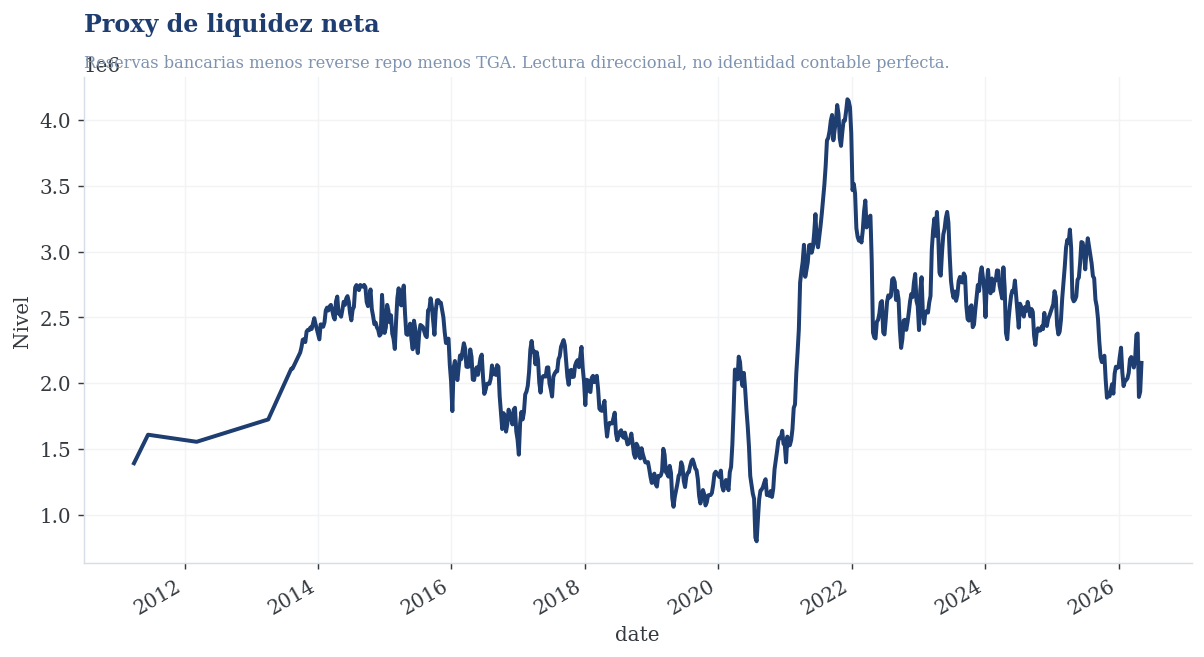

In [ ]:
# ============================================================
# Grafica: proxy de liquidez neta
# ============================================================

if "net_liquidity_proxy" in derived.columns:
    fig, ax = plt.subplots()

    derived["net_liquidity_proxy"].dropna().plot(
        ax=ax,
        color=STYLE["navy"],
        lw=2.2,
    )

    clean_axis(
        ax,
        title="Proxy de liquidez neta",
        subtitle="Reservas bancarias menos reverse repo menos TGA. Lectura direccional, no identidad contable perfecta."
    )
    ax.set_ylabel("Nivel")
    plt.show()
else:
    display(Markdown("No se pudo calcular `net_liquidity_proxy` porque faltan reservas, reverse repo o TGA."))
